In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
df=pd.read_excel(r"C:\Users\weelcome\Downloads\AmesHousing.xls")
print(df.head(5))
print(df.shape)
df.dtypes.value_counts()




   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

object     43
int64      28
float64    11
Name: count, dtype: int64

In [41]:
print(df.isnull().sum())
print(df.info())
print(df.shape)


Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 n

In [42]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)
df.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64

In [50]:

mask = df.dtypes == object
categorical_cols = df.columns[mask]
num_ohc_cols = (df[categorical_cols]
                .apply(lambda x: x.nunique())
                .sort_values(ascending=False))


# No need to encode if there is only one value
small_num_ohc_cols = num_ohc_cols.loc[num_ohc_cols>1]

# Number of one-hot columns is one less than the number of categories
small_num_ohc_cols -= 1

# This is 215 columns, assuming the original ones are dropped. 
# This is quite a few extra columns!
small_num_ohc_cols.sum()


224

In [51]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Copy of the data
data_ohc = df.copy()

# The encoders
le = LabelEncoder()
ohc = OneHotEncoder()

for col in num_ohc_cols.index:
    print(data_ohc[col])
    # Integer encode the string categories
    dat = le.fit_transform(data_ohc[col]).astype(int)
    
    # Remove the original column from the dataframe
    data_ohc = data_ohc.drop(col, axis=1)

    # One hot encode the data--this returns a sparse array
    new_dat = ohc.fit_transform(dat.reshape(-1,1))

    # Create unique column names
    n_cols = new_dat.shape[1]
    col_names = ['_'.join([col, str(x)]) for x in range(n_cols)]

    # Create the new dataframe
    new_df = pd.DataFrame(new_dat.toarray(), 
                          index=data_ohc.index, 
                          columns=col_names)

    # Append the new data to the dataframe
    data_ohc = pd.concat([data_ohc, new_df], axis=1)

0         NAmes
1         NAmes
2         NAmes
3         NAmes
4       Gilbert
         ...   
2925    Mitchel
2926    Mitchel
2927    Mitchel
2928    Mitchel
2929    Mitchel
Name: Neighborhood, Length: 2930, dtype: object
0       Plywood
1       VinylSd
2       Wd Sdng
3       BrkFace
4       VinylSd
         ...   
2925    HdBoard
2926    HdBoard
2927    Wd Shng
2928    HdBoard
2929    HdBoard
Name: Exterior 2nd, Length: 2930, dtype: object
0       BrkFace
1       VinylSd
2       Wd Sdng
3       BrkFace
4       VinylSd
         ...   
2925    HdBoard
2926    HdBoard
2927    HdBoard
2928    HdBoard
2929    HdBoard
Name: Exterior 1st, Length: 2930, dtype: object
0       WD 
1       WD 
2       WD 
3       WD 
4       WD 
       ... 
2925    WD 
2926    WD 
2927    WD 
2928    WD 
2929    WD 
Name: Sale Type, Length: 2930, dtype: object
0        Norm
1       Feedr
2        Norm
3        Norm
4        Norm
        ...  
2925     Norm
2926     Norm
2927     Norm
2928     Norm
2929     No

In [52]:
data_ohc.shape[1] - df.shape[1]

240

In [53]:
print(df.shape[1])

# Remove the string columns from the dataframe
df = df.drop(num_ohc_cols.index, axis=1)

print(df.shape[1])

82
39


In [59]:
#Train Test Split
y_col = 'SalePrice'

# Split the data that is not one-hot encoded
feature_cols = [x for x in data.columns if x != y_col]
X_data = df[feature_cols]
y_data = df[y_col]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, 
                                                    test_size=0.3, random_state=42)
# Split the data that is one-hot encoded
feature_cols = [x for x in data_ohc.columns if x != y_col]
X_data_ohc = data_ohc[feature_cols]
y_data_ohc = data_ohc[y_col]

X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_data_ohc, y_data_ohc, 
                                                    test_size=0.3, random_state=42)


In [60]:
(X_train_ohc.index == X_train.index).all()

True

In [61]:
X_train

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
2210,2211,909275030,90,82.0,6270,5,6,1949,1950,0.0,...,871.0,0,0,0,0,0,0,0,8,2007
782,783,905325020,20,65.0,25095,5,8,1968,2003,0.0,...,452.0,0,48,0,0,60,0,0,6,2009
2310,2311,527105060,60,60.0,8238,6,5,1997,1998,0.0,...,400.0,421,72,0,0,0,0,0,5,2006
299,300,909455040,120,35.0,3907,8,5,1989,1989,0.0,...,531.0,112,81,0,0,0,0,0,3,2010
2423,2424,528228415,120,68.0,3072,7,5,2004,2004,18.0,...,398.0,144,20,0,0,0,0,0,5,2006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1639,527226040,190,195.0,41600,5,5,1969,1990,0.0,...,828.0,144,0,0,0,0,0,0,11,2007
1095,1096,528290090,60,68.0,7750,7,5,2002,2002,0.0,...,403.0,100,35,0,0,0,0,0,4,2008
1130,1131,528490080,60,64.0,8791,6,5,2003,2003,0.0,...,673.0,216,56,0,0,0,0,0,5,2008
1294,1295,902109160,50,81.0,7308,5,5,1920,1950,0.0,...,225.0,0,0,236,0,0,0,0,6,2008


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

LR = LinearRegression()


error_df = list()

# Data that has not been one-hot encoded
LR = LR.fit(X_train, y_train)
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred),
                           'test' : mean_squared_error(y_test,  y_test_pred)},
                           name='no enc'))

# Data that has been one-hot encoded
LR = LR.fit(X_train_ohc, y_train_ohc)
y_train_ohc_pred = LR.predict(X_train_ohc)
y_test_ohc_pred = LR.predict(X_test_ohc)

error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
                           'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
                          name='one-hot enc'))

error_df = pd.concat(error_df, axis=1)
error_df

,no enc,one-hot enc
train,1.030565e+09,3.545716e+08
test,1.102129e+09,7.271828e+08


In [62]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler


scalers = {'standard': StandardScaler(),
           'minmax': MinMaxScaler(),
           'maxabs': MaxAbsScaler()}

training_test_sets = {
    'not_encoded': (X_train, y_train, X_test, y_test),
    'one_hot_encoded': (X_train_ohc, y_train_ohc, X_test_ohc, y_test_ohc)}


# Get the list of float columns, and the float data
# so that we don't scale something we already scaled. 
# We're supposed to scale the original data each time
mask = X_train.dtypes == float
float_columns = X_train.columns[mask]

# initialize model
LR = LinearRegression()

# iterate over all possible combinations and get the errors
errors = {}
for encoding_label, (_X_train, _y_train, _X_test, _y_test) in training_test_sets.items():
    for scaler_label, scaler in scalers.items():
        trainingset = _X_train.copy()  # copy because we dont want to scale this more than once.
        testset = _X_test.copy()
        trainingset[float_columns] = scaler.fit_transform(trainingset[float_columns])
        testset[float_columns] = scaler.transform(testset[float_columns])
        LR.fit(trainingset, _y_train)
        predictions = LR.predict(testset)
        key = encoding_label + ' - ' + scaler_label + 'scaling'
        errors[key] = mean_squared_error(_y_test, predictions)

errors = pd.Series(errors)
print(errors.to_string())
print('-' * 80)
for key, error_val in errors.items():
    print(key, error_val)

not_encoded - standardscaling        1.102129e+09
not_encoded - minmaxscaling          1.102129e+09
not_encoded - maxabsscaling          1.102129e+09
one_hot_encoded - standardscaling    7.271829e+08
one_hot_encoded - minmaxscaling      7.271829e+08
one_hot_encoded - maxabsscaling      7.271828e+08
--------------------------------------------------------------------------------
not_encoded - standardscaling 1102129240.38364
not_encoded - minmaxscaling 1102129240.4630733
not_encoded - maxabsscaling 1102129240.4631832
one_hot_encoded - standardscaling 727182859.7262205
one_hot_encoded - minmaxscaling 727182868.5860444
one_hot_encoded - maxabsscaling 727182846.1444813


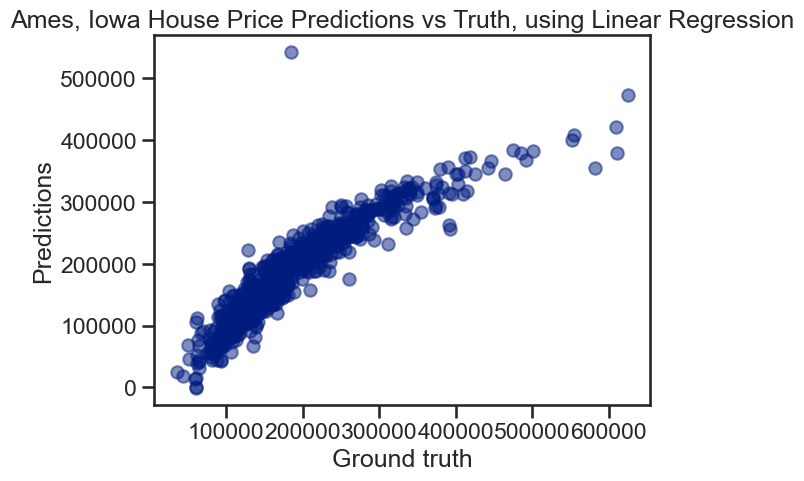

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = plt.axes()

ax.scatter(y_test, y_test_pred, alpha=.5)

ax.set(xlabel='Ground truth', 
       ylabel='Predictions',
       title='Ames, Iowa House Price Predictions vs Truth, using Linear Regression');